In [1]:
import os
for v in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS',
          'VECLIB_MAXIMUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ[v] = '1'
# then numpy / xso / ssh imports BELOW this line

In [2]:
# ── Cell 1 — imports, path & reload ───────────────────────────────────────────
import sys, os, importlib, warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../../model'))
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('../.'))

In [4]:
import importlib
import numpy as np
import seasonal_scan_harness as ssh
importlib.reload(ssh)

# Confirm the patched harness + tight tols are loaded
print(f"ssh path:               {ssh.__file__}")
print(f"SEASONAL_SOLVER_KWARGS: {ssh.SEASONAL_SOLVER_KWARGS}")
import inspect
has_mtpc = 'maxtasksperchild' in inspect.signature(ssh.run_seasonal_scan).parameters
print(f"run_seasonal_scan signature accepts maxtasksperchild: {has_mtpc}")
# expect:
#   - path under your GitHub repo, NOT under .../Claude/Projects/...
#   - atol=1e-9, rtol=1e-6, max_step=1.0, instability_neg_threshold=-1e-3

ssh path:               /Users/aoop/Documents/GitHub/SSMCariaco/parameter_scan/seasonal_scan_harness.py
SEASONAL_SOLVER_KWARGS: {'method': 'RK45', 'atol': 1e-09, 'rtol': 1e-06, 'max_step': 1.0, 'instability_neg_threshold': -0.001}
run_seasonal_scan signature accepts maxtasksperchild: True


In [6]:
# r_F axis: linear, 0.0–0.6 in 61 points (Δ=0.01).
# Dense near zero captures the post basin-flip transition (multistability boundary);
# dense above captures the pre+rec broad sweet spot.
R_F = np.linspace(0.0, 0.6, 61)
print(f"r_F axis: {R_F[0]:.3f}–{R_F[-1]:.3f}, Δ={R_F[1]-R_F[0]:.3f}, n={len(R_F)}")
print(f"total runs: {len(R_F) * 2} (= r_F × 2 eras × 1 construct × 1 param combo)")

res = ssh.run_seasonal_scan(
    constructs = ['maranon_ward'],                  # construct D — fixed
    groups     = ['pre+recovery', 'post'],          # both eras, joint scoring downstream
    fish_rates = list(R_F),
    param_grid = {                                  # construct D scalars, one-element lists
        'GGE':       [0.31],
        'mP':        [0.0015],
        'm_Z':       [0.10],
        'KsZ':       [0.23],
        'sigma_log': [0.20],
    },
    years   = 60, spinup = 15,
    save_path = 'seasonal_rF_sweep_61pt_2026-06-25.pkl',
    processes = None,                               # = cpu - 1
    maxtasksperchild = 1,                           # scipy#10070 fix
)

r_F axis: 0.000–0.600, Δ=0.010, n=61
total runs: 122 (= r_F × 2 eras × 1 construct × 1 param combo)
[seasonal scan] 122 runs: ['maranon_ward'] x ['pre+recovery', 'post'] x fish=[np.float64(0.0), np.float64(0.01), np.float64(0.02), np.float64(0.03), np.float64(0.04), np.float64(0.05), np.float64(0.06), np.float64(0.07), np.float64(0.08), np.float64(0.09), np.float64(0.1), np.float64(0.11), np.float64(0.12), np.float64(0.13), np.float64(0.14), np.float64(0.15), np.float64(0.16), np.float64(0.17), np.float64(0.18), np.float64(0.19), np.float64(0.2), np.float64(0.21), np.float64(0.22), np.float64(0.23), np.float64(0.24), np.float64(0.25), np.float64(0.26), np.float64(0.27), np.float64(0.28), np.float64(0.29), np.float64(0.3), np.float64(0.31), np.float64(0.32), np.float64(0.33), np.float64(0.34), np.float64(0.35000000000000003), np.float64(0.36), np.float64(0.37), np.float64(0.38), np.float64(0.39), np.float64(0.4), np.float64(0.41000000000000003), np.float64(0.42), np.float64(0.43), np.fl

In [7]:
print("--- per-era ranking by score (lower = better fit to obs) ---")
print(res.table(sort='score').round(3).to_string(index=False))

--- per-era ranking by score (lower = better fit to obs) ---
   construct        group  fish  GGE    mP  m_Z  KsZ  sigma_log  score  score_mean  score_med   mcs  mcs_med  micro  micro_med     N  Z200_peak  cv_sumP  mcs_conv  has_nan
maranon_ward pre+recovery  0.58 0.31 0.002  0.1 0.23        0.2  0.098       0.081      0.098 7.251    4.261  0.340      0.297 1.113      0.118    0.932     1.043    False
maranon_ward pre+recovery  0.56 0.31 0.002  0.1 0.23        0.2  0.110       0.085      0.110 7.222    4.039  0.334      0.285 1.128      0.124    0.949     0.960    False
maranon_ward pre+recovery  0.60 0.31 0.002  0.1 0.23        0.2  0.118       0.118      0.115 6.697    4.023  0.327      0.290 1.090      0.125    0.887     0.912    False
maranon_ward pre+recovery  0.54 0.31 0.002  0.1 0.23        0.2  0.121       0.101      0.121 6.996    3.955  0.329      0.280 1.135      0.155    0.951     0.989    False
maranon_ward pre+recovery  0.55 0.31 0.002  0.1 0.23        0.2  0.122       0.

In [8]:
import numpy as np, pandas as pd

# Split res.records by era, attach scores per fish rate
pre  = pd.DataFrame([r for r in res.records if r['group']=='pre+recovery']).sort_values('fish')
post = pd.DataFrame([r for r in res.records if r['group']=='post']).sort_values('fish')

# Joint pair = (pre_fish, post_fish) with pre_fish >= post_fish; joint score = max
joint = []
for _, p_row in pre.iterrows():
    for _, q_row in post.iterrows():
        if q_row['fish'] > p_row['fish']:
            continue
        joint.append(dict(
            pre_fish=p_row['fish'], post_fish=q_row['fish'],
            pre_score=p_row['score'], post_score=q_row['score'],
            joint=max(p_row['score'], q_row['score']),
            pre_mcs=p_row['mcs'], pre_mcs_med=p_row['mcs_med'],
            post_mcs=q_row['mcs'], post_mcs_med=q_row['mcs_med'],
            pre_micro=p_row['micro'], post_micro=q_row['micro'],
            pre_Z200pk=p_row['Z200_peak'], post_Z200pk=q_row['Z200_peak'],
            pre_cv=p_row['cv_sumP'], post_cv=q_row['cv_sumP'],
        ))
J = pd.DataFrame(joint).sort_values('joint').reset_index(drop=True)

print("=== top 12 joint pairs (pre_fish >= post_fish; joint = max(pre,post)) ===")
print(J.head(12).round(3).to_string(index=False))

# also locate the current pickle baseline (0.4, 0.0) for direct comparison
mask = (J.pre_fish.round(2)==0.40) & (J.post_fish.round(2)==0.00)
print("\n=== current pickle baseline (pre 0.4, post 0.0) ===")
print(J[mask].round(3).to_string(index=False))
print(f"\ncurrent baseline joint score = {float(J[mask]['joint'].iloc[0]):.3f}   "
      f"|   best joint score = {float(J['joint'].iloc[0]):.3f}   "
      f"|   improvement = {(float(J[mask]['joint'].iloc[0]) - float(J['joint'].iloc[0])):.3f}")

=== top 12 joint pairs (pre_fish >= post_fish; joint = max(pre,post)) ===
 pre_fish  post_fish  pre_score  post_score  joint  pre_mcs  pre_mcs_med  post_mcs  post_mcs_med  pre_micro  post_micro  pre_Z200pk  post_Z200pk  pre_cv  post_cv
     0.43       0.12      0.156       0.164  0.164    6.210        3.673     3.235         2.309      0.309         0.2       0.196        0.093   0.946    0.422
     0.49       0.12      0.151       0.164  0.164    6.336        3.697     3.235         2.309      0.307         0.2       0.170        0.093   0.949    0.422
     0.55       0.12      0.122       0.164  0.164    7.171        3.951     3.235         2.309      0.332         0.2       0.149        0.093   0.959    0.422
     0.56       0.12      0.110       0.164  0.164    7.222        4.039     3.235         2.309      0.334         0.2       0.124        0.093   0.949    0.422
     0.59       0.12      0.126       0.164  0.164    7.111        3.853     3.235         2.309      0.326         


##############################################################################
## TOP-1:  pre_fish=0.430   post_fish=0.120
##############################################################################

[TOP-1 | pre+recovery | r_F=0.430]
=== diagnose [pre+recovery] ===
metric    mod_mean  obs_mean   mod_med   obs_med  d_mean   d_med
mcs           6.21      8.65      3.67      4.84   -0.28   -0.24
pico         0.467     0.436       0.5     0.429   +0.07   +0.17
nano         0.224     0.217     0.225     0.205   +0.03   +0.09
micro        0.309     0.346     0.266     0.271   -0.11   -0.02
sumP         0.738     0.633      0.53     0.535   +0.17   -0.01
N             1.23      1.51     0.948      1.29   -0.19   -0.26
PP            0.16     0.542     0.141      0.28   -0.71   -0.50
Export        2.34      3.52      2.27      2.64   -0.34   -0.14
Z200         0.039    0.0533    0.0199     0.053   -0.27   -0.63
Z500       0.00909    0.0302   0.00023    0.0235   -0.70   -0.99
score   mean=0

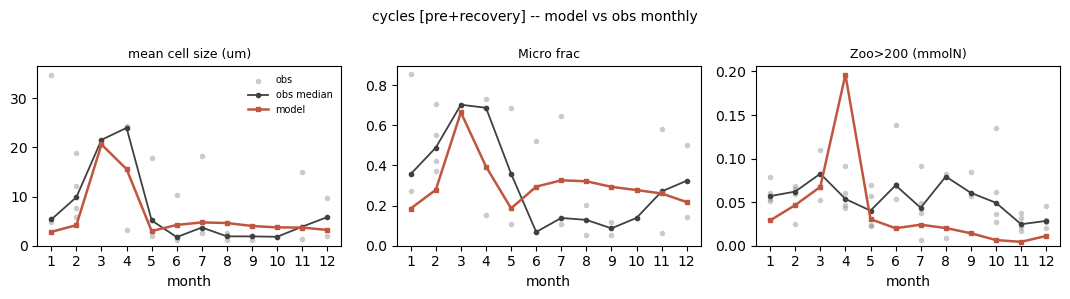

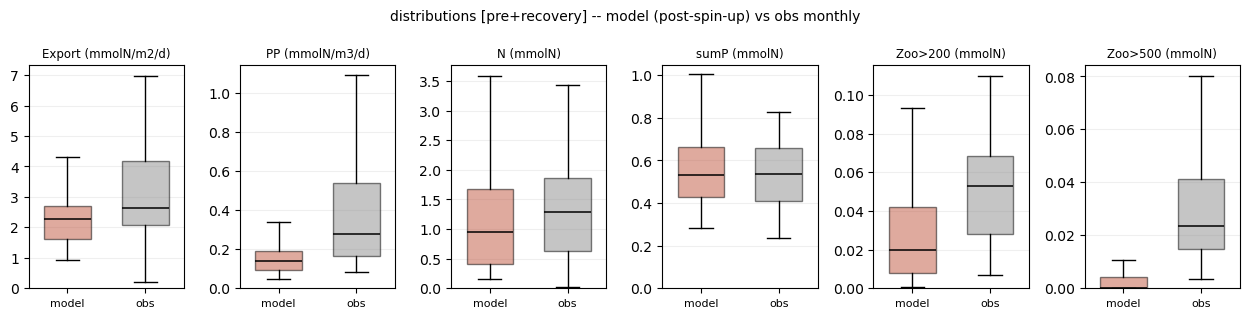

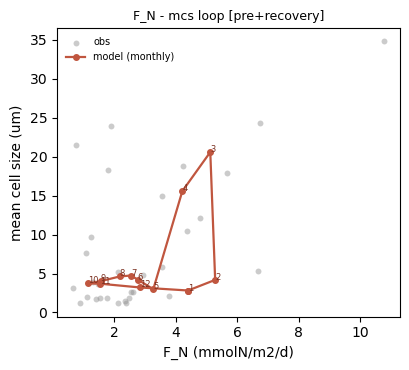


[TOP-1 | post | r_F=0.120]
=== diagnose [post] ===
metric    mod_mean  obs_mean   mod_med   obs_med  d_mean   d_med
mcs           3.24      4.67      2.31      2.32   -0.31   -0.00
pico          0.56     0.542     0.591     0.562   +0.03   +0.05
nano         0.241     0.267     0.241     0.272   -0.10   -0.11
micro          0.2     0.191     0.155     0.124   +0.05   +0.25
sumP          0.47     0.581     0.392     0.459   -0.19   -0.15
N            0.753      1.23     0.464     0.959   -0.39   -0.52
PP           0.113     0.324    0.0952     0.202   -0.65   -0.53
Export           2      2.67       1.8      2.17   -0.25   -0.17
Z200        0.0342     0.066    0.0213    0.0566   -0.48   -0.62
Z500       0.00707    0.0371  2.38e-05    0.0334   -0.81   -1.00
score   mean=0.164  med=0.139  joint(max)=0.164   (on ['mcs', 'pico', 'nano', 'micro'])
flags   has_nan=False nan_frac=0.00 mcs_conv=1.00 Z200_peak=0.093 cv_sumP=0.42
        floor   minP=0.0000  minZ=0.0000   (post-spin-up min over 

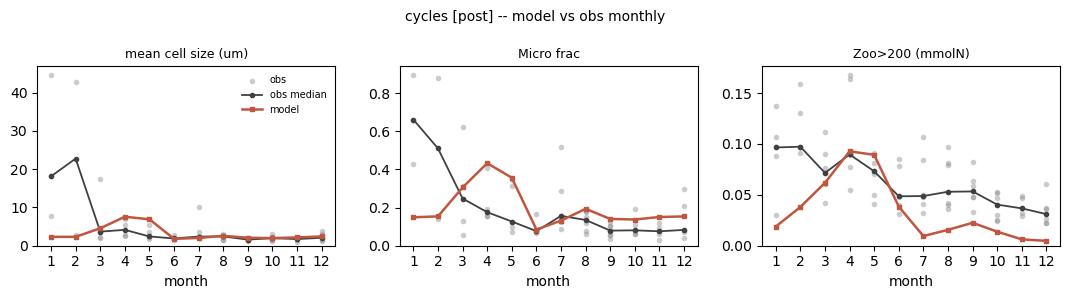

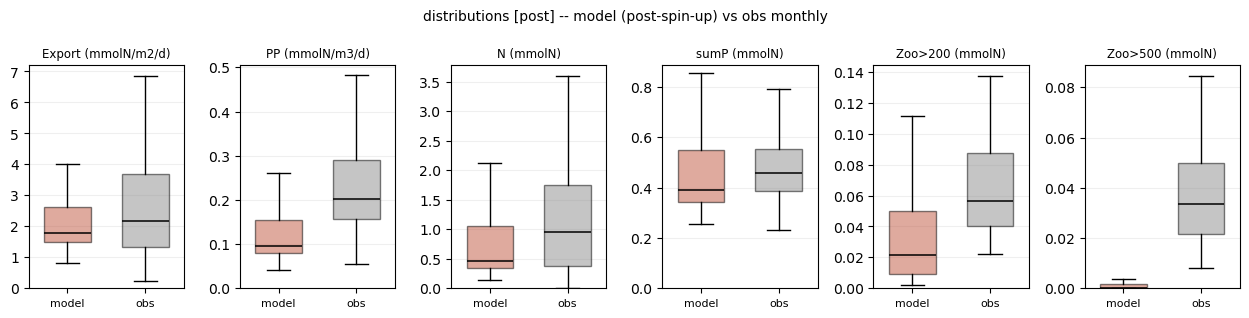

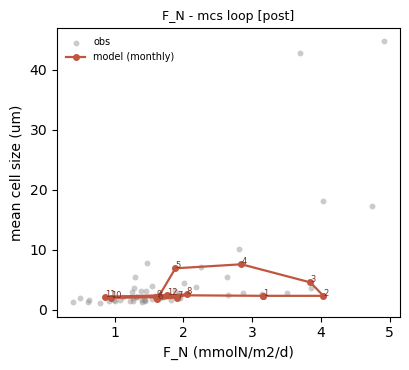


##############################################################################
## TOP-2:  pre_fish=0.490   post_fish=0.120
##############################################################################

[TOP-2 | pre+recovery | r_F=0.490]
=== diagnose [pre+recovery] ===
metric    mod_mean  obs_mean   mod_med   obs_med  d_mean   d_med
mcs           6.34      8.65      3.69      4.84   -0.27   -0.24
pico         0.466     0.436     0.492     0.429   +0.07   +0.15
nano         0.226     0.217     0.229     0.205   +0.04   +0.12
micro        0.307     0.346     0.263     0.271   -0.11   -0.03
sumP         0.742     0.633     0.524     0.535   +0.17   -0.02
N             1.17      1.51     0.911      1.29   -0.23   -0.29
PP           0.158     0.542     0.141      0.28   -0.71   -0.50
Export        2.29      3.52      2.23      2.64   -0.35   -0.16
Z200        0.0358    0.0533    0.0187     0.053   -0.33   -0.65
Z500       0.00641    0.0302  8.67e-05    0.0235   -0.79   -1.00
score   mean=0

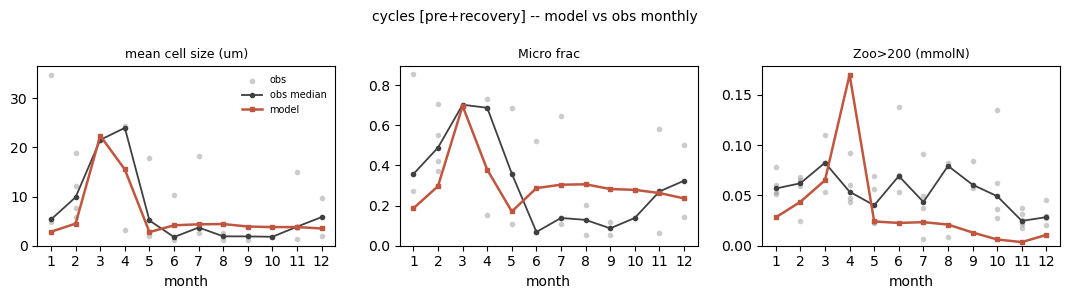

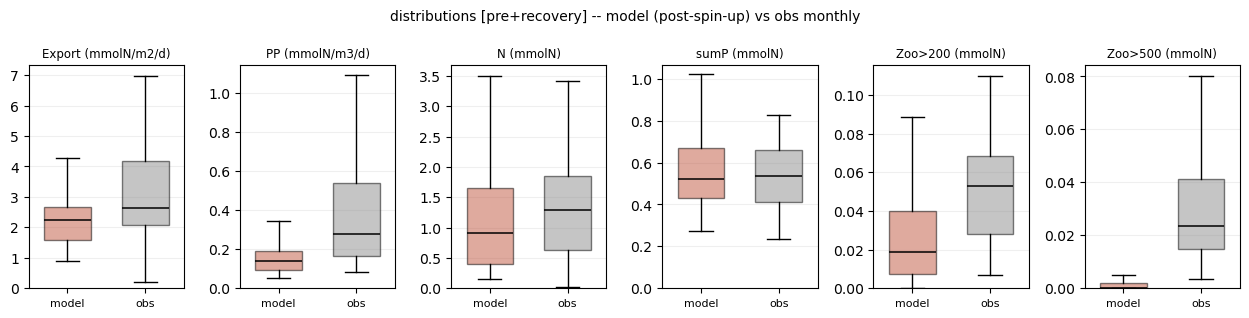

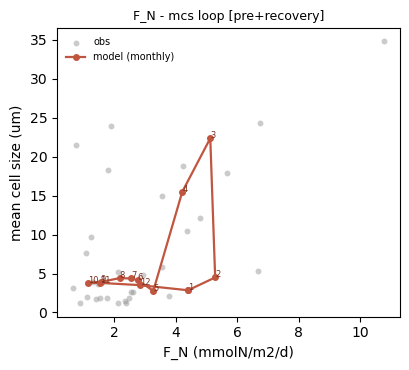


[TOP-2 | post | r_F=0.120]
=== diagnose [post] ===
metric    mod_mean  obs_mean   mod_med   obs_med  d_mean   d_med
mcs           3.24      4.67      2.31      2.32   -0.31   -0.00
pico          0.56     0.542     0.591     0.562   +0.03   +0.05
nano         0.241     0.267     0.241     0.272   -0.10   -0.11
micro          0.2     0.191     0.155     0.124   +0.05   +0.25
sumP          0.47     0.581     0.392     0.459   -0.19   -0.15
N            0.753      1.23     0.464     0.959   -0.39   -0.52
PP           0.113     0.324    0.0952     0.202   -0.65   -0.53
Export           2      2.67       1.8      2.17   -0.25   -0.17
Z200        0.0342     0.066    0.0213    0.0566   -0.48   -0.62
Z500       0.00707    0.0371  2.38e-05    0.0334   -0.81   -1.00
score   mean=0.164  med=0.139  joint(max)=0.164   (on ['mcs', 'pico', 'nano', 'micro'])
flags   has_nan=False nan_frac=0.00 mcs_conv=1.00 Z200_peak=0.093 cv_sumP=0.42
        floor   minP=0.0000  minZ=0.0000   (post-spin-up min over 

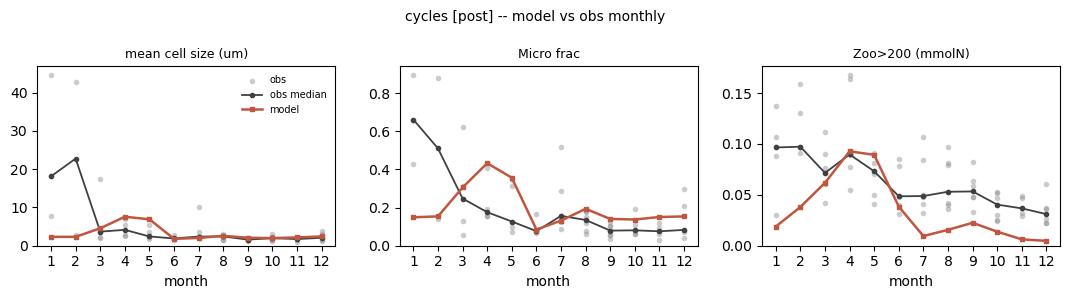

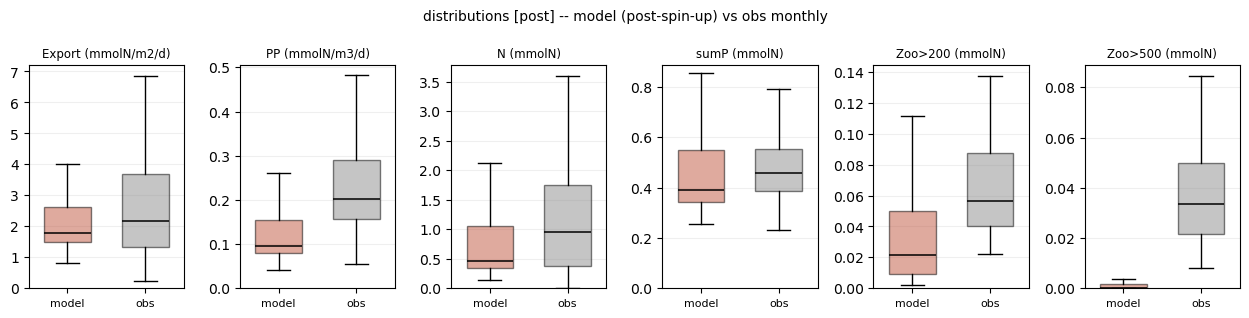

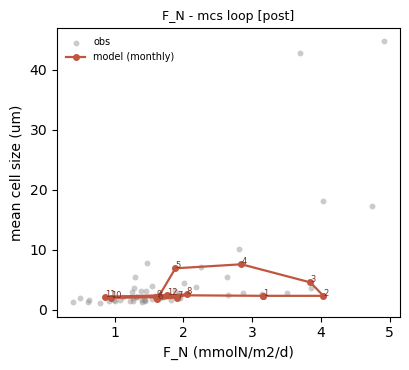


##############################################################################
## alt low-post:  pre_fish=0.430   post_fish=0.070
##############################################################################

[alt low-post | pre+recovery | r_F=0.430]
=== diagnose [pre+recovery] ===
metric    mod_mean  obs_mean   mod_med   obs_med  d_mean   d_med
mcs           6.21      8.65      3.67      4.84   -0.28   -0.24
pico         0.467     0.436       0.5     0.429   +0.07   +0.17
nano         0.224     0.217     0.225     0.205   +0.03   +0.09
micro        0.309     0.346     0.266     0.271   -0.11   -0.02
sumP         0.738     0.633      0.53     0.535   +0.17   -0.01
N             1.23      1.51     0.948      1.29   -0.19   -0.26
PP            0.16     0.542     0.141      0.28   -0.71   -0.50
Export        2.34      3.52      2.27      2.64   -0.34   -0.14
Z200         0.039    0.0533    0.0199     0.053   -0.27   -0.63
Z500       0.00909    0.0302   0.00023    0.0235   -0.70   -0.99


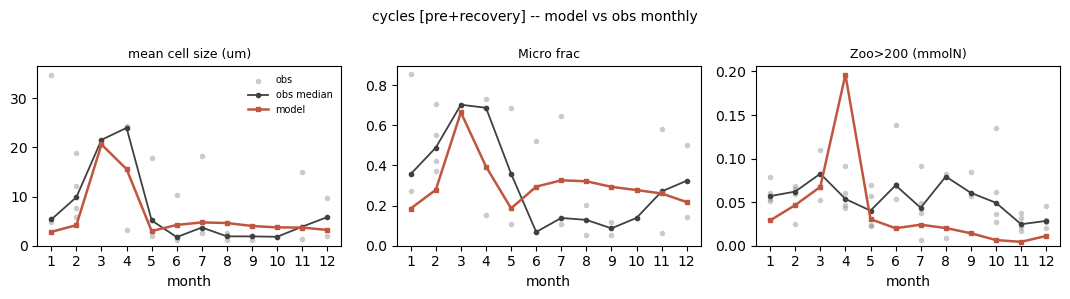

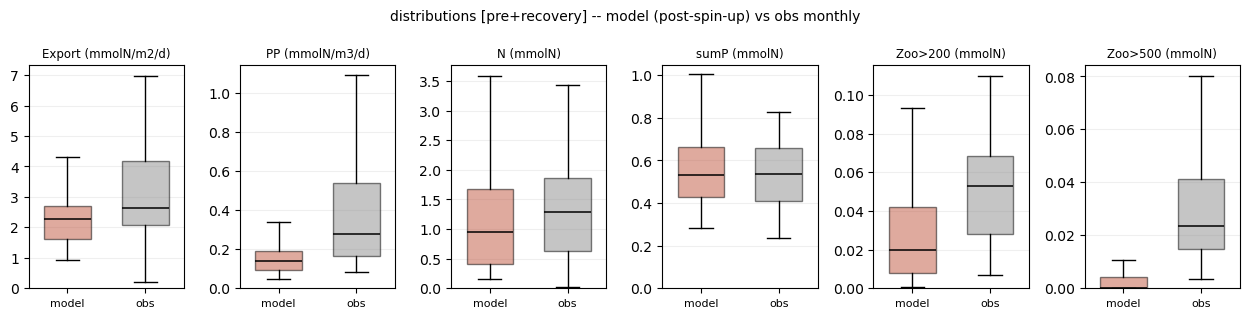

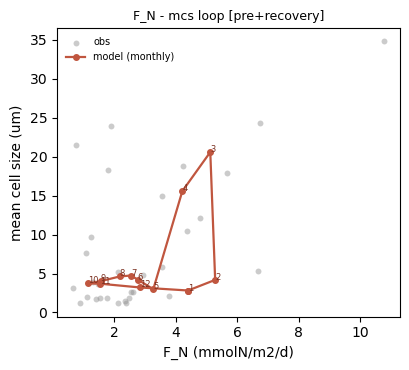


[alt low-post | post | r_F=0.070]
=== diagnose [post] ===
metric    mod_mean  obs_mean   mod_med   obs_med  d_mean   d_med
mcs           3.09      4.67      2.22      2.32   -0.34   -0.04
pico         0.567     0.542       0.6     0.562   +0.05   +0.07
nano         0.245     0.267     0.245     0.272   -0.08   -0.10
micro        0.188     0.191     0.145     0.124   -0.02   +0.17
sumP         0.467     0.581     0.391     0.459   -0.20   -0.15
N            0.794      1.23     0.476     0.959   -0.36   -0.50
PP           0.115     0.324    0.0966     0.202   -0.64   -0.52
Export        2.06      2.67      1.84      2.17   -0.23   -0.15
Z200         0.039     0.066    0.0244    0.0566   -0.41   -0.57
Z500        0.0112    0.0371   0.00054    0.0334   -0.70   -0.98
score   mean=0.176  med=0.108  joint(max)=0.176   (on ['mcs', 'pico', 'nano', 'micro'])
flags   has_nan=False nan_frac=0.00 mcs_conv=1.00 Z200_peak=0.116 cv_sumP=0.43
        floor   minP=0.0000  minZ=0.0000   (post-spin-up mi

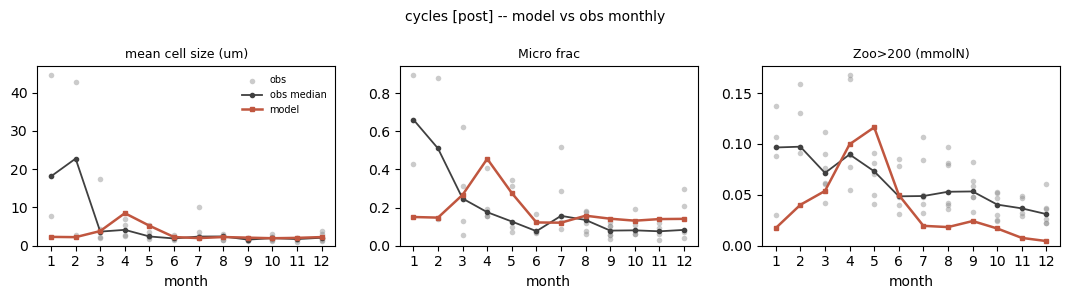

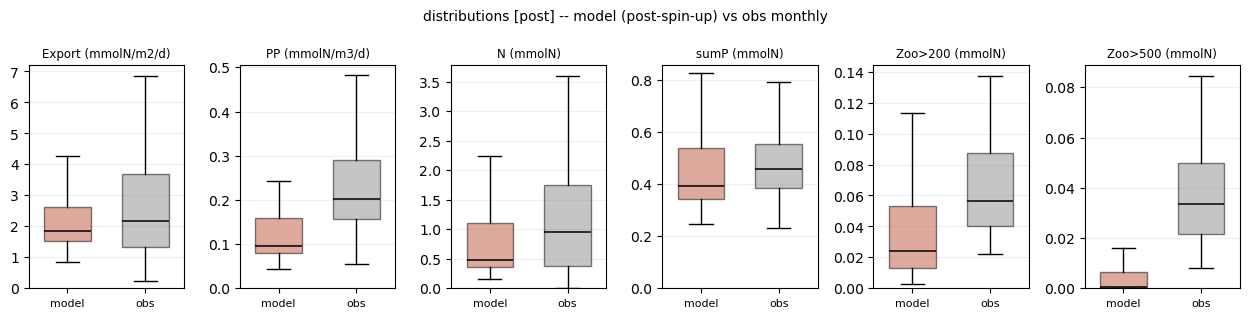

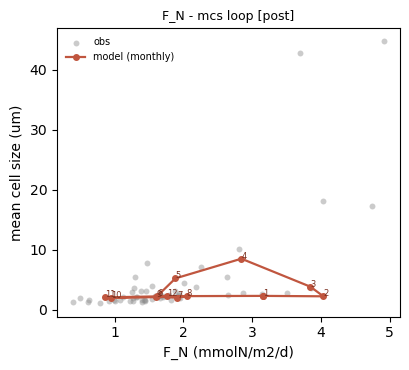


##############################################################################
## PICKLE current:  pre_fish=0.400   post_fish=0.000
##############################################################################

[PICKLE current | pre+recovery | r_F=0.400]
=== diagnose [pre+recovery] ===
metric    mod_mean  obs_mean   mod_med   obs_med  d_mean   d_med
mcs           6.76      8.65      3.29      4.84   -0.22   -0.32
pico          0.47     0.436     0.517     0.429   +0.08   +0.20
nano         0.223     0.217     0.232     0.205   +0.03   +0.13
micro        0.307     0.346     0.239     0.271   -0.11   -0.12
sumP         0.785     0.633     0.505     0.535   +0.24   -0.06
N             1.27      1.51     0.907      1.29   -0.16   -0.29
PP           0.158     0.542     0.136      0.28   -0.71   -0.51
Export        2.31      3.52      2.23      2.64   -0.34   -0.15
Z200        0.0366    0.0533    0.0168     0.053   -0.31   -0.68
Z500        0.0135    0.0302  0.000179    0.0235   -0.55   -0

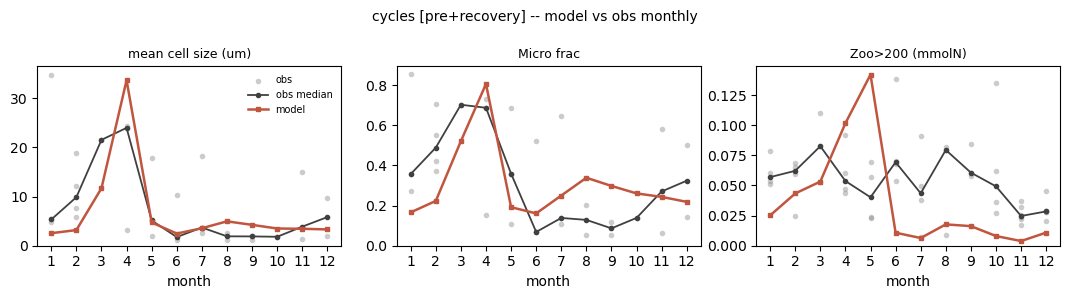

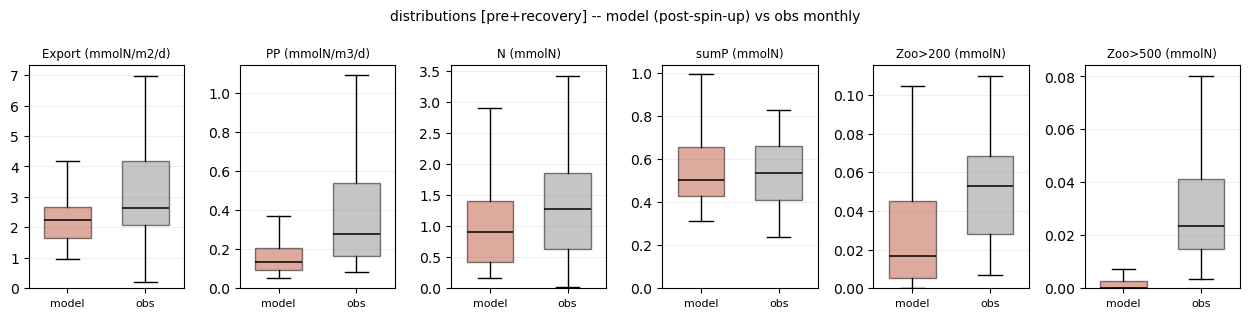

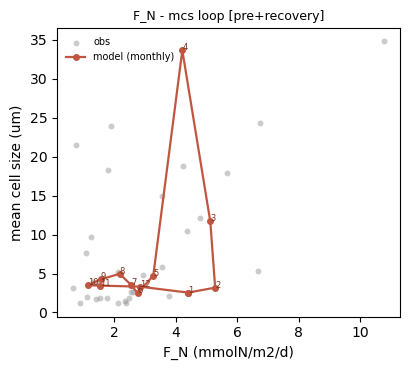


[PICKLE current | post | r_F=0.000]
=== diagnose [post] ===
metric    mod_mean  obs_mean   mod_med   obs_med  d_mean   d_med
mcs           3.12      4.67      2.51      2.32   -0.33   +0.08
pico         0.551     0.542     0.569     0.562   +0.02   +0.01
nano         0.248     0.267     0.247     0.272   -0.07   -0.09
micro        0.201     0.191     0.173     0.124   +0.05   +0.40
sumP         0.472     0.581     0.434     0.459   -0.19   -0.05
N            0.816      1.23     0.491     0.959   -0.34   -0.49
PP           0.118     0.324    0.0991     0.202   -0.63   -0.51
Export        2.16      2.67      1.92      2.17   -0.19   -0.12
Z200        0.0547     0.066    0.0378    0.0566   -0.17   -0.33
Z500         0.016    0.0371   0.00309    0.0334   -0.57   -0.91
score   mean=0.172  med=0.208  joint(max)=0.208   (on ['mcs', 'pico', 'nano', 'micro'])
flags   has_nan=False nan_frac=0.00 mcs_conv=0.99 Z200_peak=0.143 cv_sumP=0.34
        floor   minP=0.0000  minZ=0.0000   (post-spin-up 

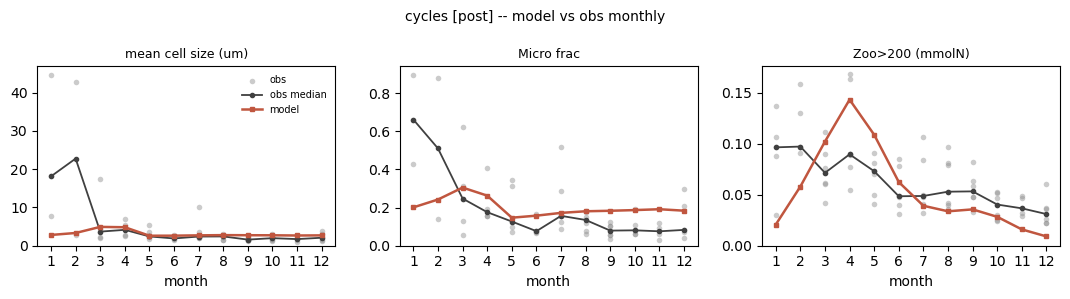

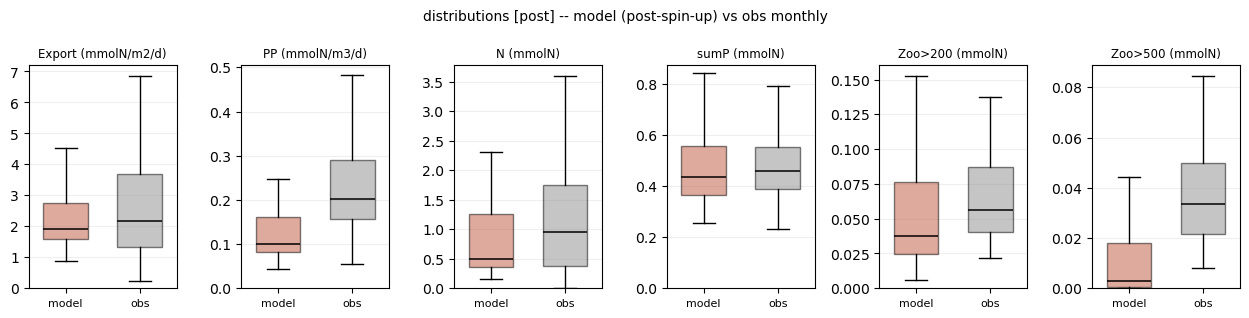

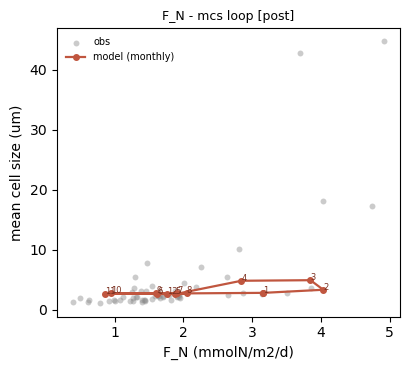

In [9]:
import seasonal_diagnostics as sd
import importlib; importlib.reload(sd)

# Pick what to inspect: top 2 joint pairs from Cell A + the current pickle
CANDS = [
    ('TOP-1',          dict(pre=float(J.iloc[0].pre_fish), post=float(J.iloc[0].post_fish))),
    ('TOP-2',          dict(pre=float(J.iloc[1].pre_fish), post=float(J.iloc[1].post_fish))),
    ('alt low-post',   dict(pre=float(J.iloc[0].pre_fish), post=0.07)),    # see if a lower post r_F kept above the basin flip changes the picture
    ('PICKLE current', dict(pre=0.4, post=0.0)),                            # baseline for comparison
]

forc  = ssh.build_forcings(['pre+recovery', 'post'])
obs_t = ssh.build_obs_targets(['pre+recovery', 'post'])
obs_m = ssh.build_obs_monthly(['pre+recovery', 'post'])
spec  = ssh.allometry('maranon_ward')

def _run_one(group, fish):
    return ssh.run_one(spec, forc[group], fish_rate=fish, years=60, spinup=15,
                       mP=0.0015, m_Z=0.10,
                       grazing={'KsZ': 0.23, 'sigma_log': 0.20},
                       iv_overrides={'GrazingRouter': {'gge': 0.31}},
                       return_traj=True)

for tag, fishes in CANDS:
    print('\n' + '#'*78)
    print(f"## {tag}:  pre_fish={fishes['pre']:.3f}   post_fish={fishes['post']:.3f}")
    print('#'*78)
    for g, f_key in [('pre+recovery', 'pre'), ('post', 'post')]:
        clim, r = _run_one(g, fishes[f_key])
        sd.diagnose(clim, r, g, spinup=15,
                    obs_targets=obs_t, obs_monthly=obs_m,
                    title=f"\n[{tag} | {g} | r_F={fishes[f_key]:.3f}]")

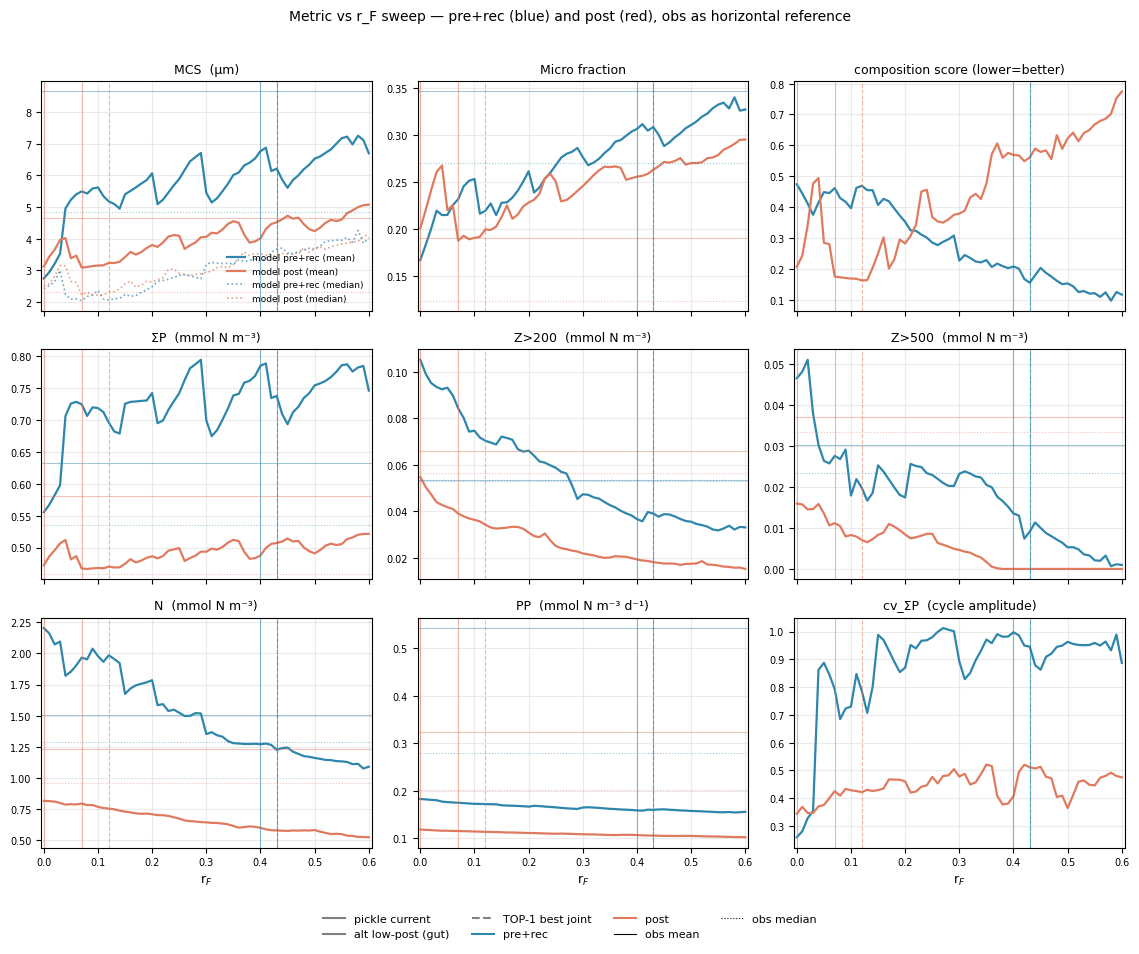

r_F that minimises |model − obs_mean| per metric, per era
metric       pre best r_F   pre model   pre obs     post best r_F  post model  post obs
mcs                 0.580      7.2509    8.6466             0.470      4.6626    4.6677
micro               0.580      0.3402    0.3464             0.100      0.1908    0.1910
sumP                0.030      0.5975    0.6326             0.600      0.5214    0.5811
Z200                0.280      0.0512    0.0533             0.000      0.0547    0.0660
Z500                0.040      0.0303    0.0302             0.000      0.0160    0.0371
N                   0.290      1.5176    1.5089             0.000      0.8156    1.2345
PP                  0.000      0.1824    0.5423             0.000      0.1181    0.3235

Z>500 max-biomass r_F:  pre+rec = 0.020  (value = 0.0511, obs = 0.0302)
Z>500 max-biomass r_F:  post     = 0.000  (value = 0.0160, obs = 0.0371)


In [10]:
import numpy as np, matplotlib.pyplot as plt

# pre and post DataFrames from Cell A (already sorted by 'fish')
# Each record has obs_<metric>_mean and obs_<metric>_med per era

# Reference r_F pairs to mark visually (vertical lines)
REF = [
    (0.40, 0.00, 'pickle current',     '#999999', '-'),
    (0.43, 0.07, 'alt low-post (gut)', '#222222', '-'),   # your pick
    (0.43, 0.12, 'TOP-1 best joint',   '#2E86AB', '--'),
]

# Panels: (model_key, label, obs_basename, log_y)
PANELS = [
    ('mcs',     'MCS  (µm)',         'mcs',   False),
    ('micro',   'Micro fraction',    'micro', False),
    ('score',   'composition score (lower=better)', None, False),
    ('sumP',    'ΣP  (mmol N m⁻³)',  'sumP',  False),
    ('Z200',    'Z>200  (mmol N m⁻³)','Z200', False),
    ('Z500',    'Z>500  (mmol N m⁻³)','Z500', False),
    ('N',       'N  (mmol N m⁻³)',   'N',     False),
    ('PP',      'PP  (mmol N m⁻³ d⁻¹)', 'PP', False),
    ('cv_sumP', 'cv_ΣP  (cycle amplitude)', None, False),
]

fig, axes = plt.subplots(3, 3, figsize=(11.5, 9.5), sharex=True)
PRE_C, POST_C = '#2E86AB', '#E07A5F'

for ax, (mkey, mlabel, obs_base, log_y) in zip(axes.flat, PANELS):
    # model curves vs r_F (long-run mean), both eras
    if mkey in pre.columns:
        ax.plot(pre['fish'],  pre[mkey],  '-', color=PRE_C,  lw=1.6, label='model pre+rec (mean)')
    if mkey in post.columns:
        ax.plot(post['fish'], post[mkey], '-', color=POST_C, lw=1.6, label='model post (mean)')

    # MCS gets the median overlay too (the cycle-amplitude split matters here)
    if mkey == 'mcs':
        ax.plot(pre['fish'],  pre['mcs_med'],  ':', color=PRE_C,  lw=1.2, alpha=0.7, label='model pre+rec (median)')
        ax.plot(post['fish'], post['mcs_med'], ':', color=POST_C, lw=1.2, alpha=0.7, label='model post (median)')

    # obs reference (horizontal lines per era)
    if obs_base is not None:
        om_pre  = float(pre.iloc[0].get(f'obs_{obs_base}_mean', np.nan))
        om_post = float(post.iloc[0].get(f'obs_{obs_base}_mean', np.nan))
        od_pre  = float(pre.iloc[0].get(f'obs_{obs_base}_med',  np.nan))
        od_post = float(post.iloc[0].get(f'obs_{obs_base}_med',  np.nan))
        if np.isfinite(om_pre):  ax.axhline(om_pre,  color=PRE_C,  ls='-',  lw=0.8, alpha=0.45)
        if np.isfinite(om_post): ax.axhline(om_post, color=POST_C, ls='-',  lw=0.8, alpha=0.45)
        if np.isfinite(od_pre):  ax.axhline(od_pre,  color=PRE_C,  ls=':',  lw=0.8, alpha=0.45)
        if np.isfinite(od_post): ax.axhline(od_post, color=POST_C, ls=':',  lw=0.8, alpha=0.45)

    # candidate r_F vertical lines
    for r_pre, r_post, lbl, col, ls in REF:
        ax.axvline(r_pre,  color=PRE_C,  ls=ls, lw=0.8, alpha=0.55)
        ax.axvline(r_post, color=POST_C, ls=ls, lw=0.8, alpha=0.55)

    if log_y: ax.set_yscale('log')
    ax.set_title(mlabel, fontsize=9)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.25)
    ax.set_xlim(-0.005, 0.605)

axes[0,0].legend(fontsize=6.5, frameon=False, loc='lower right')
for ax in axes[-1,:]:
    ax.set_xlabel(r'r$_F$', fontsize=9)

# legend for the candidate markers (separately at the bottom)
import matplotlib.lines as mlines
handles = [mlines.Line2D([], [], color='gray', lw=1.5, ls=ls, label=lbl)
           for r_pre, r_post, lbl, col, ls in REF]
handles += [mlines.Line2D([], [], color=PRE_C,  lw=1.5, label='pre+rec'),
            mlines.Line2D([], [], color=POST_C, lw=1.5, label='post'),
            mlines.Line2D([], [], color='black', lw=0.8, ls='-', label='obs mean'),
            mlines.Line2D([], [], color='black', lw=0.8, ls=':', label='obs median')]
fig.legend(handles=handles, fontsize=8, ncol=4, loc='lower center', bbox_to_anchor=(0.5, -0.01),
           frameon=False)
fig.suptitle('Metric vs r_F sweep — pre+rec (blue) and post (red), obs as horizontal reference',
             fontsize=10)
fig.tight_layout(rect=(0,0.04,1,0.97))
plt.show()

# numerical: where each metric is "best" matched per era
print("=" * 78)
print("r_F that minimises |model − obs_mean| per metric, per era")
print("=" * 78)
print(f"{'metric':<10}{'pre best r_F':>15}{'pre model':>12}{'pre obs':>10}   "
      f"{'post best r_F':>15}{'post model':>12}{'post obs':>10}")
for mkey, _, obs_base, _ in PANELS:
    if obs_base is None: continue
    om_pre  = float(pre.iloc[0].get(f'obs_{obs_base}_mean', np.nan))
    om_post = float(post.iloc[0].get(f'obs_{obs_base}_mean', np.nan))
    j_pre  = int(np.argmin(np.abs(pre[mkey].values  - om_pre)))  if np.isfinite(om_pre) else None
    j_post = int(np.argmin(np.abs(post[mkey].values - om_post))) if np.isfinite(om_post) else None
    pre_best = f"{pre['fish'].iloc[j_pre]:.3f}" if j_pre is not None else '   --'
    pre_mv   = f"{pre[mkey].iloc[j_pre]:.4f}"   if j_pre is not None else '   --'
    post_best= f"{post['fish'].iloc[j_post]:.3f}" if j_post is not None else '   --'
    post_mv  = f"{post[mkey].iloc[j_post]:.4f}"   if j_post is not None else '   --'
    print(f"{mkey:<10}{pre_best:>15}{pre_mv:>12}{om_pre:>10.4f}   "
          f"{post_best:>15}{post_mv:>12}{om_post:>10.4f}")

# Z>500 specifically — where it peaks per era (Benny's specific question)
print(f"\nZ>500 max-biomass r_F:  pre+rec = {pre['fish'].iloc[int(np.argmax(pre['Z500']))]:.3f}  "
      f"(value = {pre['Z500'].max():.4f}, obs = {float(pre.iloc[0]['obs_Z500_mean']):.4f})")
print(f"Z>500 max-biomass r_F:  post     = {post['fish'].iloc[int(np.argmax(post['Z500']))]:.3f}  "
      f"(value = {post['Z500'].max():.4f}, obs = {float(post.iloc[0]['obs_Z500_mean']):.4f})")

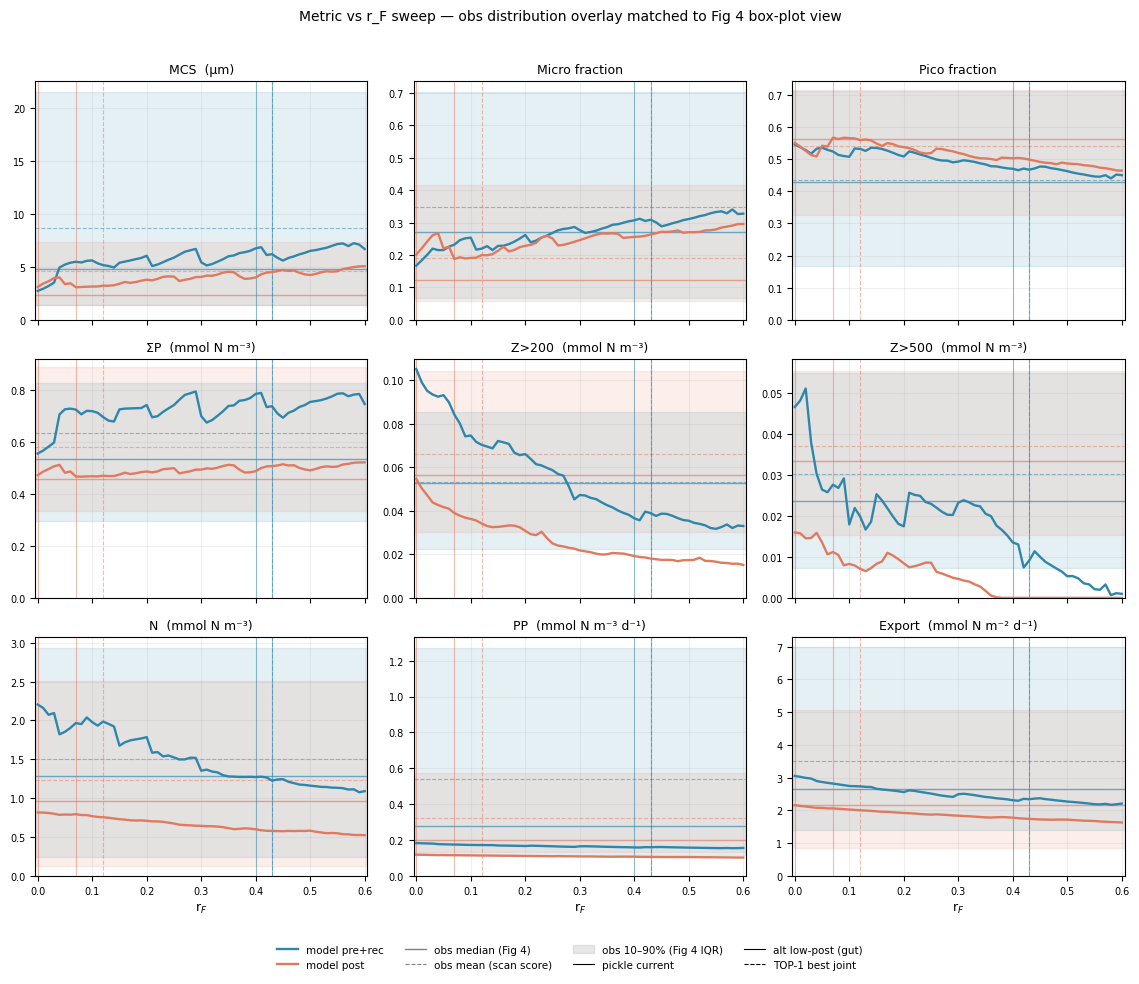

metric  era              obs_med  obs_mean   obs_p10   obs_p90     n     med/mean
mcs     pre+recovery      4.8412    8.6466    1.4103   21.5385    31        0.560
mcs     post              2.3179    4.6677    1.4243    7.3929    57        0.497
micro   pre+recovery      0.2706    0.3464    0.0677    0.7029    31        0.781
micro   post              0.1239    0.1910    0.0595    0.4163    57        0.649
pico    pre+recovery      0.4291    0.4363    0.1690    0.7131    31        0.983
pico    post              0.5617    0.5418    0.3262    0.7152    57        1.037
sumP    pre+recovery      0.5349    0.6326    0.2959    0.8280    31        0.846
sumP    post              0.4589    0.5811    0.3325    0.8886    57        0.790
Z200    pre+recovery      0.0530    0.0533    0.0225    0.0856    49        0.996
Z200    post              0.0566    0.0660    0.0304    0.1042    74        0.857
Z500    pre+recovery      0.0235    0.0302    0.0073    0.0549    48        0.780
Z500    post    

In [11]:
import numpy as np, matplotlib.pyplot as plt
import seasonal_scan_harness as ssh

# obs monthly distributions — matched to Fig 4 (forcing_complete=True, the default)
obs_m = ssh.build_obs_monthly(['pre+recovery', 'post'], forcing_complete=True)
ERAS = ['pre+recovery', 'post']

# Reference r_F candidates (vertical lines)
REF = [
    (0.40, 0.00, 'pickle current',     '-'),
    (0.43, 0.07, 'alt low-post (gut)', '-'),
    (0.43, 0.12, 'TOP-1 best joint',   '--'),
]

# Panels: (model_key, label, obs_col_in_obs_monthly)
PANELS = [
    ('mcs',     'MCS  (µm)',                'mcs'),
    ('micro',   'Micro fraction',           'micro'),
    ('pico',    'Pico fraction',            'pico'),
    ('sumP',    'ΣP  (mmol N m⁻³)',         'sumP'),
    ('Z200',    'Z>200  (mmol N m⁻³)',      'Z200'),
    ('Z500',    'Z>500  (mmol N m⁻³)',      'Z500'),
    ('N',       'N  (mmol N m⁻³)',          'N'),
    ('PP',      'PP  (mmol N m⁻³ d⁻¹)',     'PP'),
    ('Export',  'Export  (mmol N m⁻² d⁻¹)', 'Export'),
]

PRE_C, POST_C = '#2E86AB', '#E07A5F'
fig, axes = plt.subplots(3, 3, figsize=(11.5, 9.8), sharex=True)

obs_summary = {}   # for the diagnostic print

for ax, (mkey, mlabel, obs_col) in zip(axes.flat, PANELS):
    # obs distribution per era — median + 10/90%
    for era, col, df_key in [('pre+recovery', PRE_C, 'pre'), ('post', POST_C, 'post')]:
        v = obs_m[era][obs_col].dropna().values.astype(float)
        v = v[np.isfinite(v)]
        if v.size == 0:
            continue
        omd  = float(np.median(v))
        omn  = float(np.mean(v))
        olo, ohi = np.percentile(v, [10, 90])
        obs_summary[(era, mkey)] = dict(median=omd, mean=omn, p10=olo, p90=ohi, n=int(v.size))

        # 10-90% shaded band, median solid, mean dashed (the scan's target)
        ax.axhspan(olo, ohi, color=col, alpha=0.12, zorder=0)
        ax.axhline(omd, color=col, ls='-',  lw=1.0, alpha=0.65, zorder=1)
        ax.axhline(omn, color=col, ls='--', lw=0.8, alpha=0.50, zorder=1)

    # model curves
    if mkey in pre.columns:
        ax.plot(pre['fish'],  pre[mkey],  '-', color=PRE_C,  lw=1.7, label='model pre+rec', zorder=3)
    if mkey in post.columns:
        ax.plot(post['fish'], post[mkey], '-', color=POST_C, lw=1.7, label='model post',     zorder=3)

    # candidate r_F markers
    for r_pre, r_post, lbl, ls in REF:
        ax.axvline(r_pre,  color=PRE_C,  ls=ls, lw=0.8, alpha=0.5, zorder=2)
        ax.axvline(r_post, color=POST_C, ls=ls, lw=0.8, alpha=0.5, zorder=2)

    ax.set_title(mlabel, fontsize=9)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.2, zorder=0)
    ax.set_xlim(-0.005, 0.605)
    ax.set_ylim(bottom=0)

for ax in axes[-1,:]:
    ax.set_xlabel(r'r$_F$', fontsize=9)

# bottom legend
import matplotlib.lines as mlines, matplotlib.patches as mpatches
handles = [
    mlines.Line2D([], [], color=PRE_C,  lw=1.7, label='model pre+rec'),
    mlines.Line2D([], [], color=POST_C, lw=1.7, label='model post'),
    mlines.Line2D([], [], color='gray', lw=1.0, ls='-',  label='obs median (Fig 4)'),
    mlines.Line2D([], [], color='gray', lw=0.8, ls='--', label='obs mean (scan score)'),
    mpatches.Patch(color='gray', alpha=0.18, label='obs 10–90% (Fig 4 IQR)'),
]
for r_pre, r_post, lbl, ls in REF:
    handles.append(mlines.Line2D([], [], color='black', lw=0.8, ls=ls, label=lbl))

fig.legend(handles=handles, fontsize=7.5, ncol=4, loc='lower center',
           bbox_to_anchor=(0.5, -0.01), frameon=False)
fig.suptitle('Metric vs r_F sweep — obs distribution overlay matched to Fig 4 box-plot view',
             fontsize=10)
fig.tight_layout(rect=(0, 0.04, 1, 0.97))
plt.show()

# === per-metric obs distribution table — what the scan score targets vs what Fig 4 shows ===
print("=" * 95)
print(f"{'metric':<8}{'era':<14}{'obs_med':>10}{'obs_mean':>10}{'obs_p10':>10}{'obs_p90':>10}{'n':>6}   "
      f"{'med/mean':>10}")
print("=" * 95)
for mkey, _, _ in PANELS:
    for era in ERAS:
        if (era, mkey) not in obs_summary: continue
        d = obs_summary[(era, mkey)]
        ratio = d['median'] / d['mean'] if d['mean'] != 0 else np.nan
        print(f"{mkey:<8}{era:<14}{d['median']:>10.4f}{d['mean']:>10.4f}"
              f"{d['p10']:>10.4f}{d['p90']:>10.4f}{d['n']:>6d}   {ratio:>10.3f}")

# === per-candidate: model values vs whether they fall within obs 10-90% (Fig 4 IQR) ===
def _near(arr, v): return int(np.argmin(np.abs(arr - v)))
print("\n" + "=" * 95)
print("Per candidate (pre, post): model value vs whether it sits inside the Fig 4 obs IQR")
print("=" * 95)
for r_pre, r_post, lbl, _ in REF:
    print(f"\n--- {lbl}: pre_fish={r_pre}, post_fish={r_post} ---")
    j_pre, j_post = _near(pre['fish'].values, r_pre), _near(post['fish'].values, r_post)
    print(f"  {'metric':<10}{'mod (pre)':>12}{'in IQR?':>10}   {'mod (post)':>12}{'in IQR?':>10}")
    for mkey, _, _ in PANELS:
        if mkey not in pre.columns: continue
        mp = float(pre[mkey].iloc[j_pre]); mq = float(post[mkey].iloc[j_post])
        d_pre  = obs_summary.get(('pre+recovery', mkey), None)
        d_post = obs_summary.get(('post', mkey), None)
        flag_pre  = '✓' if d_pre  and (d_pre['p10']  <= mp <= d_pre['p90'])  else '✗'
        flag_post = '✓' if d_post and (d_post['p10'] <= mq <= d_post['p90']) else '✗'
        print(f"  {mkey:<10}{mp:>12.4f}{flag_pre:>10}   {mq:>12.4f}{flag_post:>10}")

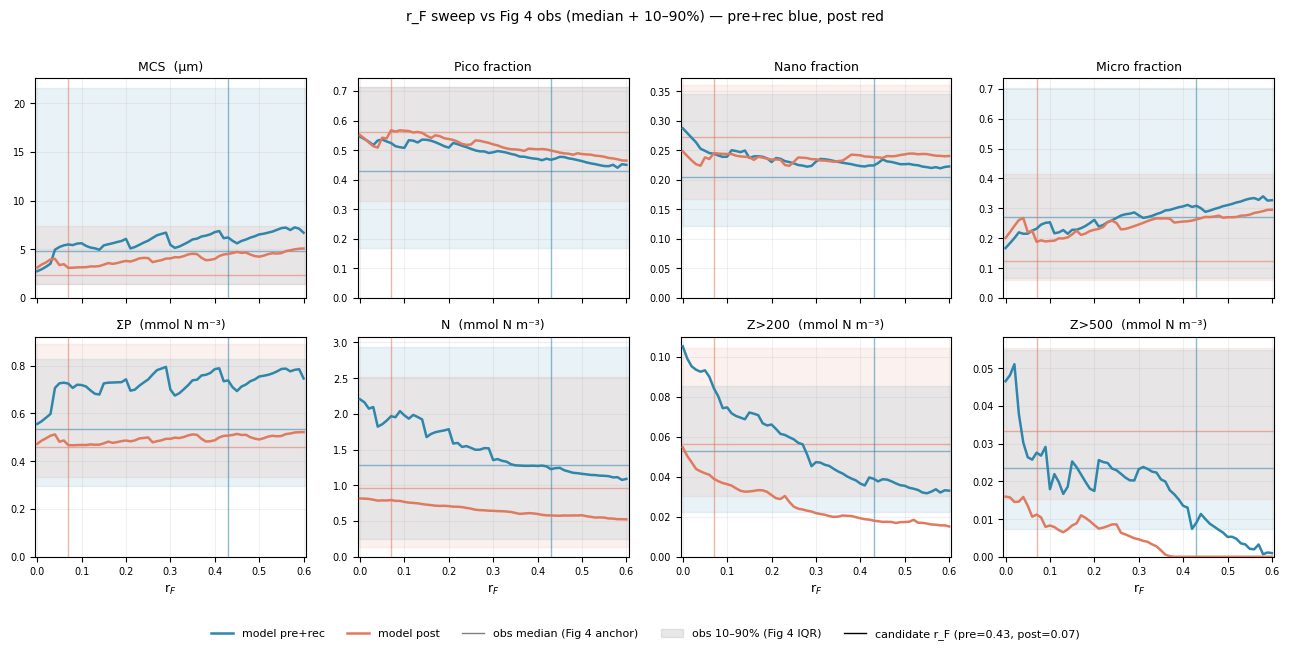


Candidate (pre=0.43, post=0.07):  how many of the 8 metrics sit inside obs 10–90%?
  metric     mod_pre           obs IQR pre     mod_post          obs IQR post
  mcs         6.2100  [1.4103, 21.5385]   ✓       3.0863  [1.4243, 7.3929]   ✓
  pico        0.4673  [0.1690, 0.7131]   ✓       0.5672  [0.3262, 0.7152]   ✓
  nano        0.2242  [0.1212, 0.3450]   ✓       0.2451  [0.1682, 0.3596]   ✓
  micro       0.3086  [0.0677, 0.7029]   ✓       0.1877  [0.0595, 0.4163]   ✓
  sumP        0.7376  [0.2959, 0.8280]   ✓       0.4670  [0.3325, 0.8886]   ✓
  N           1.2253  [0.2432, 2.9309]   ✓       0.7940  [0.1324, 2.5133]   ✓
  Z200        0.0390  [0.0225, 0.0856]   ✓       0.0390  [0.0304, 0.1042]   ✓
  Z500        0.0091  [0.0073, 0.0549]   ✓       0.0112  [0.0153, 0.0555]   ✗

→ pre+rec hits 8/8 metrics inside obs IQR; post hits 7/8.


In [12]:
import numpy as np, matplotlib.pyplot as plt
import seasonal_scan_harness as ssh
import matplotlib.lines as mlines, matplotlib.patches as mpatches

obs_m = ssh.build_obs_monthly(['pre+recovery', 'post'], forcing_complete=True)
ERAS = ['pre+recovery', 'post']

# Exactly the 8 metrics in Fig 4 (b) panels — nothing else.
PANELS = [
    ('mcs',    'MCS  (µm)',          'mcs'),
    ('pico',   'Pico fraction',      'pico'),
    ('nano',   'Nano fraction',      'nano'),
    ('micro',  'Micro fraction',     'micro'),
    ('sumP',   'ΣP  (mmol N m⁻³)',   'sumP'),
    ('N',      'N  (mmol N m⁻³)',    'N'),
    ('Z200',   'Z>200  (mmol N m⁻³)','Z200'),
    ('Z500',   'Z>500  (mmol N m⁻³)','Z500'),
]

# Only the gut-pick as a marker — keep the visuals quiet.
PICK = (0.43, 0.07, 'alt low-post (gut)')

PRE_C, POST_C = '#2E86AB', '#E07A5F'
fig, axes = plt.subplots(2, 4, figsize=(13, 6.4), sharex=True)

obs_summary = {}
for ax, (mkey, mlabel, obs_col) in zip(axes.flat, PANELS):
    for era, col in [('pre+recovery', PRE_C), ('post', POST_C)]:
        v = obs_m[era][obs_col].dropna().values.astype(float); v = v[np.isfinite(v)]
        if v.size == 0: continue
        omd, olo, ohi = float(np.median(v)), *np.percentile(v, [10, 90])
        obs_summary[(era, mkey)] = dict(median=omd, p10=olo, p90=ohi, n=int(v.size))
        # Fig 4 anchor: obs median solid + 10-90% band shaded
        ax.axhspan(olo, ohi, color=col, alpha=0.10, zorder=0)
        ax.axhline(omd,      color=col, lw=1.0, alpha=0.55, zorder=1)

    # Model curve (long-run mean from scan)
    if mkey in pre.columns:  ax.plot(pre['fish'],  pre[mkey],  '-', color=PRE_C,  lw=1.8, zorder=3)
    if mkey in post.columns: ax.plot(post['fish'], post[mkey], '-', color=POST_C, lw=1.8, zorder=3)

    # Single vertical line each: the candidate the eye is testing
    r_pre, r_post, _ = PICK
    ax.axvline(r_pre,  color=PRE_C,  lw=1.0, alpha=0.55, zorder=2)
    ax.axvline(r_post, color=POST_C, lw=1.0, alpha=0.55, zorder=2)

    ax.set_title(mlabel, fontsize=9)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.18, zorder=0)
    ax.set_xlim(-0.005, 0.605)
    ax.set_ylim(bottom=0)

for ax in axes[-1,:]:
    ax.set_xlabel(r'r$_F$', fontsize=9)

handles = [
    mlines.Line2D([], [], color=PRE_C,  lw=1.8, label='model pre+rec'),
    mlines.Line2D([], [], color=POST_C, lw=1.8, label='model post'),
    mlines.Line2D([], [], color='gray', lw=1.0, label='obs median (Fig 4 anchor)'),
    mpatches.Patch(color='gray', alpha=0.18, label='obs 10–90% (Fig 4 IQR)'),
    mlines.Line2D([], [], color='black', lw=1.0, label=f"candidate r_F (pre={PICK[0]}, post={PICK[1]})"),
]
fig.legend(handles=handles, fontsize=8, ncol=5, loc='lower center',
           bbox_to_anchor=(0.5, -0.02), frameon=False)
fig.suptitle('r_F sweep vs Fig 4 obs (median + 10–90%) — pre+rec blue, post red', fontsize=10)
fig.tight_layout(rect=(0, 0.04, 1, 0.97))
plt.show()

# Compact per-candidate verdict: how many of the 8 metrics fall inside obs IQR?
print(f"\nCandidate (pre={PICK[0]}, post={PICK[1]}):  "
      f"how many of the 8 metrics sit inside obs 10–90%?")
def _near(arr, v): return int(np.argmin(np.abs(arr - v)))
j_pre, j_post = _near(pre['fish'].values, PICK[0]), _near(post['fish'].values, PICK[1])
hits_pre, hits_post = 0, 0
print(f"  {'metric':<8}{'mod_pre':>10}{'obs IQR pre':>22}   {'mod_post':>10}{'obs IQR post':>22}")
for mkey, _, _ in PANELS:
    if mkey not in pre.columns: continue
    mp, mq = float(pre[mkey].iloc[j_pre]), float(post[mkey].iloc[j_post])
    d_pre, d_post = obs_summary.get(('pre+recovery', mkey)), obs_summary.get(('post', mkey))
    in_pre  = d_pre  and d_pre['p10']  <= mp <= d_pre['p90']
    in_post = d_post and d_post['p10'] <= mq <= d_post['p90']
    hits_pre  += int(bool(in_pre))
    hits_post += int(bool(in_post))
    print(f"  {mkey:<8}{mp:>10.4f}  [{d_pre['p10']:6.4f}, {d_pre['p90']:6.4f}]  {'✓' if in_pre else '✗':>2}   "
          f"{mq:>10.4f}  [{d_post['p10']:6.4f}, {d_post['p90']:6.4f}]  {'✓' if in_post else '✗':>2}")
print(f"\n→ pre+rec hits {hits_pre}/8 metrics inside obs IQR; "
      f"post hits {hits_post}/8.")